# Test CLUE performance

In this notebook, we test counterfactual generation for many dimensions of both classifier and autoencoder backbones. The four setups will be:

- Non-Bayesian & Unsupervised
- Non-Bayesian & Supervised
- Bayesian & Unsupervised
- Bayesian & Supervised

We will use the MNIST dataset for this test.

## Setup


In [1]:
inDrive = True

In [2]:
import sys
import os

if inDrive:
    from google.colab import drive
    drive.mount('/content/drive')
    os.chdir('/content/drive/My Drive/Hybrid-CLUE/MyImplementation/testing_notebooks')

# Get current directory and parent directory
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)

# Add parent directory to path if not already there
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

Mounted at /content/drive


Import libraries

In [3]:
import importlib
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os

import models.BLL
import models.mnist_classifier_BLL
import train
import sampler
import models.regene_models


Set the configuration

In [4]:
# 1. Configuration
class Config:
    # Data
    batch_size = 512
    latent_dim = 256

    # Hardware
    device = 'cuda' if torch.cuda.is_available() \
    else 'mps' if torch.backends.mps.is_available() \
    else 'cpu'

    train=False

cfg = Config()

In [39]:
# Print the current working directory to help with file paths
import os
print(f"Current working directory: {os.getcwd()}")

base_dir = '../model_saves'
models_dir = '../model_saves/big_test'
results_dir = '../results/big_test_2'
os.makedirs(models_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

Current working directory: /content/drive/My Drive/Hybrid-CLUE/MyImplementation/testing_notebooks


In [6]:
dimensions = [16, 32, 64, 128, 256]

## Backbone
Load all backbones

### Load chosen model

Load model

In [7]:
from models.regene_models import Decoder, Classifier
importlib.reload(models.regene_models)

models_list = []

for latent_dim in dimensions:
    decoder = models.regene_models.Decoder(latent_dim=latent_dim, device=cfg.device)
    backbone = models.regene_models.Classifier(latent_dim=latent_dim, num_classes=10, device=cfg.device)

    backbone.load(os.path.join(models_dir, f'joint_classifier_{latent_dim}.pth'))
    decoder.load(os.path.join(models_dir, f'joint_decoder_{latent_dim}.pth'))
    name = f'joint_training_BLL_{latent_dim}'
    models_list.append((backbone, decoder, name, latent_dim))

Loaded classifier model from: ../model_saves/big_test/joint_classifier_16.pth
Loaded decoder model from: ../model_saves/big_test/joint_decoder_16.pth
Loaded classifier model from: ../model_saves/big_test/joint_classifier_32.pth
Loaded decoder model from: ../model_saves/big_test/joint_decoder_32.pth
Loaded classifier model from: ../model_saves/big_test/joint_classifier_64.pth
Loaded decoder model from: ../model_saves/big_test/joint_decoder_64.pth
Loaded classifier model from: ../model_saves/big_test/joint_classifier_128.pth
Loaded decoder model from: ../model_saves/big_test/joint_decoder_128.pth
Loaded classifier model from: ../model_saves/big_test/joint_classifier_256.pth
Loaded decoder model from: ../model_saves/big_test/joint_decoder_256.pth


Load the Datasets

In [8]:
# Load the MNIST dataset
transform = transforms.Compose([transforms.ToTensor()])
trainset = torchvision.datasets.MNIST(root='../data', train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST(root='../data', train=False, download=True, transform=transform)

# Split training set into train and validation
train_size = int(0.8 * len(trainset))
val_size = len(trainset) - train_size
trainset, valset = torch.utils.data.random_split(trainset, [train_size, val_size])

trainloader = torch.utils.data.DataLoader(trainset, batch_size=cfg.batch_size, shuffle=True, num_workers=2)
valloader = torch.utils.data.DataLoader(valset, batch_size=cfg.batch_size, shuffle=False, num_workers=2)
testloader = torch.utils.data.DataLoader(testset, batch_size=cfg.batch_size, shuffle=False, num_workers=2)

Create a models and results directory if it doesn't exist

## Bayesian Last Layer - VI
Next we'll train a variational inference version of the Bayesian last layer using the chosen backbone.


In [9]:
if inDrive:
    %pip install torchbnn

In [10]:
print(cfg.device)

cuda


### Load the model

In [11]:
from models.BLL_VI import BayesianLastLayerVI
importlib.reload(models.BLL_VI)
from train import train_BLL_VI_classification
importlib.reload(train)


import os
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

save_dir = os.path.join(models_dir, 'BLL_VI')
os.makedirs(save_dir, exist_ok=True)

last_layer_models = []

for backbone, decoder, name, latent_dim in models_list:

    bll_vi = BayesianLastLayerVI(
        backbone=backbone,
        input_dim=latent_dim,  # Matches backbone's encoder output
        output_dim=10,  # MNIST classes
        device=cfg.device
    )

    # Verify all model components are on the correct device
    print(f"Backbone device: {next(bll_vi.backbone.parameters()).device}")
    print(f"Last layer device: {next(bll_vi.last_layer.parameters()).device}")

    bll_vi.load_checkpoint(os.path.join(models_dir, 'BLL_VI', f'BLL_VI_joint_training_BLL_{latent_dim}.pt'))

    last_layer_models.append(bll_vi)

Backbone device: cuda:0
Last layer device: cuda:0
 [load_checkpoint] Loaded checkpoint from ../model_saves/big_test/BLL_VI/BLL_VI_joint_training_BLL_16.pt
Backbone device: cuda:0
Last layer device: cuda:0
 [load_checkpoint] Loaded checkpoint from ../model_saves/big_test/BLL_VI/BLL_VI_joint_training_BLL_32.pt
Backbone device: cuda:0
Last layer device: cuda:0
 [load_checkpoint] Loaded checkpoint from ../model_saves/big_test/BLL_VI/BLL_VI_joint_training_BLL_64.pt
Backbone device: cuda:0
Last layer device: cuda:0
 [load_checkpoint] Loaded checkpoint from ../model_saves/big_test/BLL_VI/BLL_VI_joint_training_BLL_128.pt
Backbone device: cuda:0
Last layer device: cuda:0
 [load_checkpoint] Loaded checkpoint from ../model_saves/big_test/BLL_VI/BLL_VI_joint_training_BLL_256.pt


### Test the model
To check for Bayesian behaviour, we find an uncertain prediction and visualize multiple samples from the posterior.


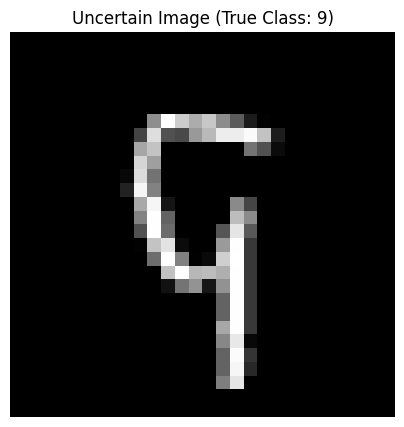

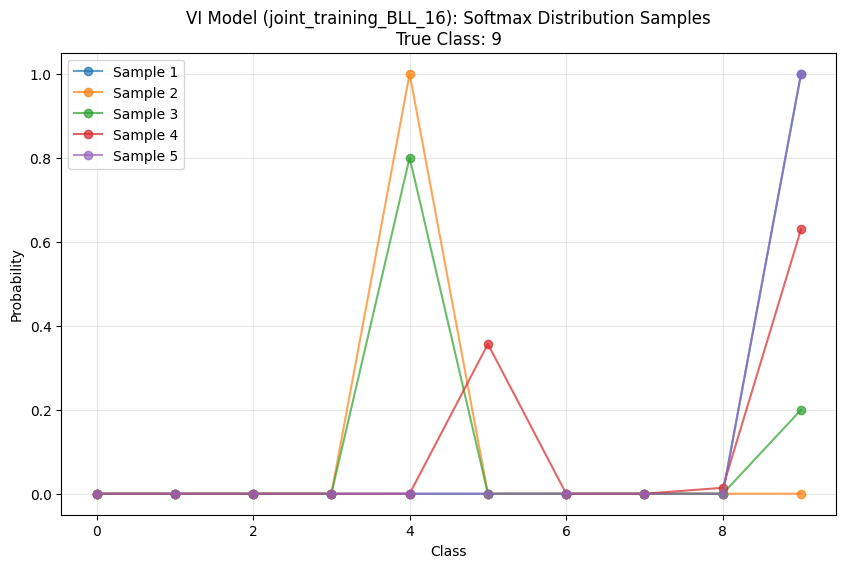

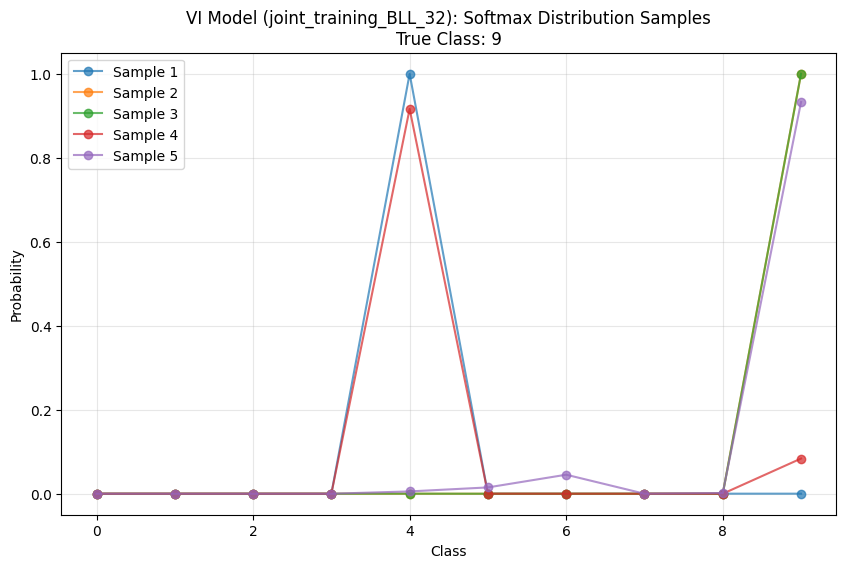

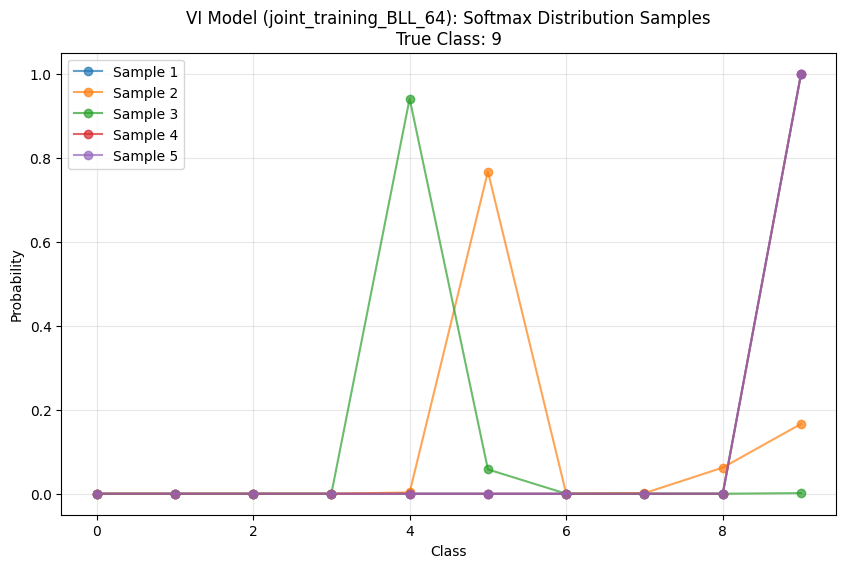

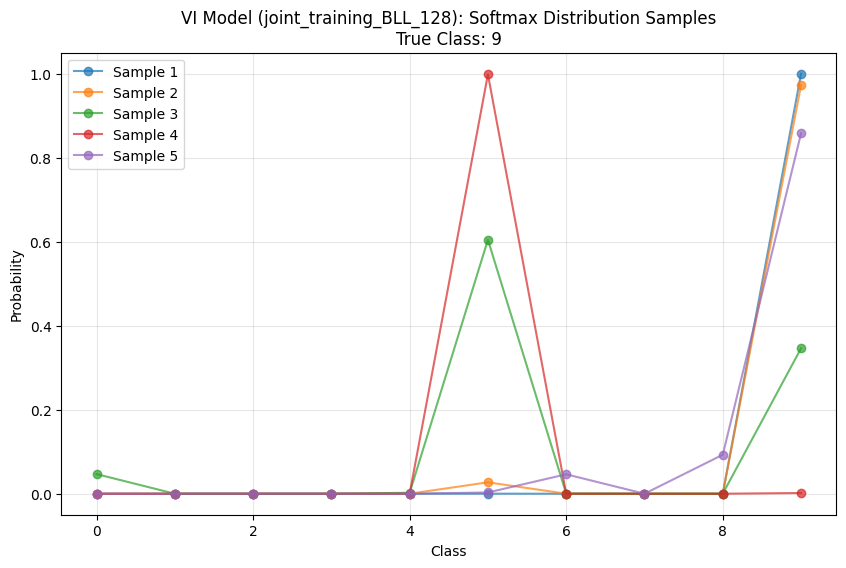

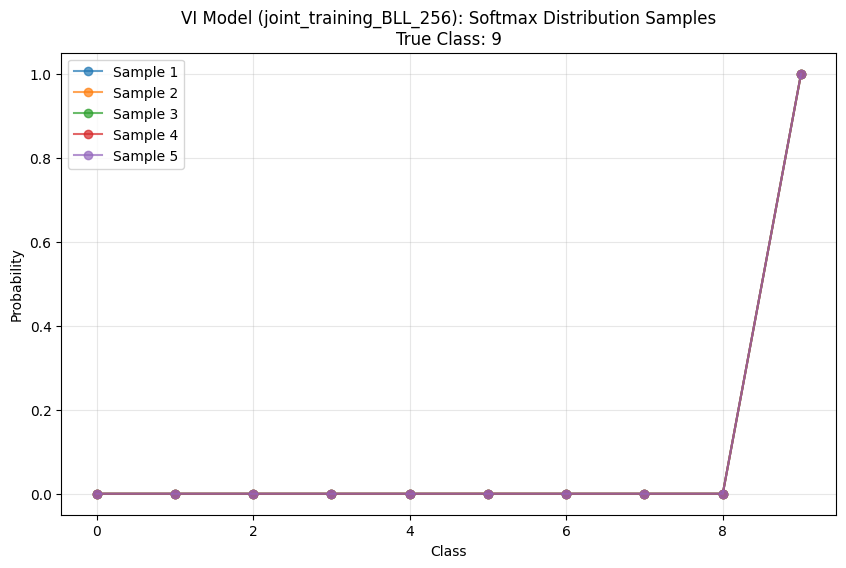

In [12]:
import torch.nn.functional as F

# Search for an uncertain prediction across all models
test_iter = iter(testloader)
found_uncertain = False
max_tries = 100
num_samples = 5

try:
    while not found_uncertain and max_tries > 0:
        x, y = next(test_iter)
        max_tries -= 1

        # Look at each example in the batch
        for i in range(len(x)):
            x_single = x[i:i+1].to(cfg.device)
            y_single = y[i:i+1]

            # Check if this example is uncertain across all models
            all_models_uncertain = True

            for model in last_layer_models:
                # Get multiple predictions for this single example
                outputs = []
                with torch.no_grad():
                    for _ in range(num_samples):
                        logits = model(x_single)
                        probs = F.softmax(logits, dim=1)
                        outputs.append(probs)

                # Stack predictions
                probs = torch.stack(outputs)  # Shape: [num_samples, 1, num_classes]
                probs = probs.squeeze(1)  # Remove batch dimension -> [num_samples, num_classes]

                # Check if predictions are not all highly confident
                max_probs = probs.max(dim=1)[0]
                if max_probs.mean() >= 0.95:  # If average confidence is high
                    all_models_uncertain = False
                    break

            if all_models_uncertain:
                found_uncertain = True
                uncertain_x = x_single
                uncertain_y = y_single
                break

except StopIteration:
    if not found_uncertain:
        print("Could not find uncertain prediction in entire test set")

# If we found an uncertain example, plot the softmax distributions for each model
if found_uncertain:
    # Display the uncertain image
    plt.figure(figsize=(5, 5))
    img = uncertain_x.squeeze().cpu()
    if img.shape[0] == 1:  # If grayscale, remove channel dimension
        img = img.squeeze(0)
    plt.imshow(img, cmap='gray' if len(img.shape) == 2 else None)
    plt.axis('off')
    plt.title(f'Uncertain Image (True Class: {uncertain_y.item()})')
    plt.show()

    # Plot the softmax distributions for each model
    for idx, model in enumerate(last_layer_models):
        # Get multiple predictions for this single example
        outputs = []
        with torch.no_grad():
            for _ in range(num_samples):
                logits = model(uncertain_x)
                probs = F.softmax(logits, dim=1)
                outputs.append(probs)

        # Stack predictions
        probs = torch.stack(outputs)  # Shape: [num_samples, 1, num_classes]
        probs = probs.squeeze(1)  # Remove batch dimension -> [num_samples, num_classes]

        # Plot the softmax distributions
        plt.figure(figsize=(10, 6))
        x_axis = range(probs.shape[1])  # Range over number of classes

        for i in range(num_samples):
            plt.plot(x_axis, probs[i].detach().cpu().numpy(), 'o-', alpha=0.7, label=f'Sample {i+1}')

        model_name = f"Model {idx+1}" if idx < len(models_list) else f"Model {idx+1}"
        if idx < len(models_list):
            model_name = models_list[idx][2]  # Use the name from models_list

        plt.xlabel('Class')
        plt.ylabel('Probability')
        plt.title(f'VI Model ({model_name}): Softmax Distribution Samples\nTrue Class: {uncertain_y.item()}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
else:
    print("No uncertain examples found. Try increasing max_tries or adjusting the uncertainty threshold.")

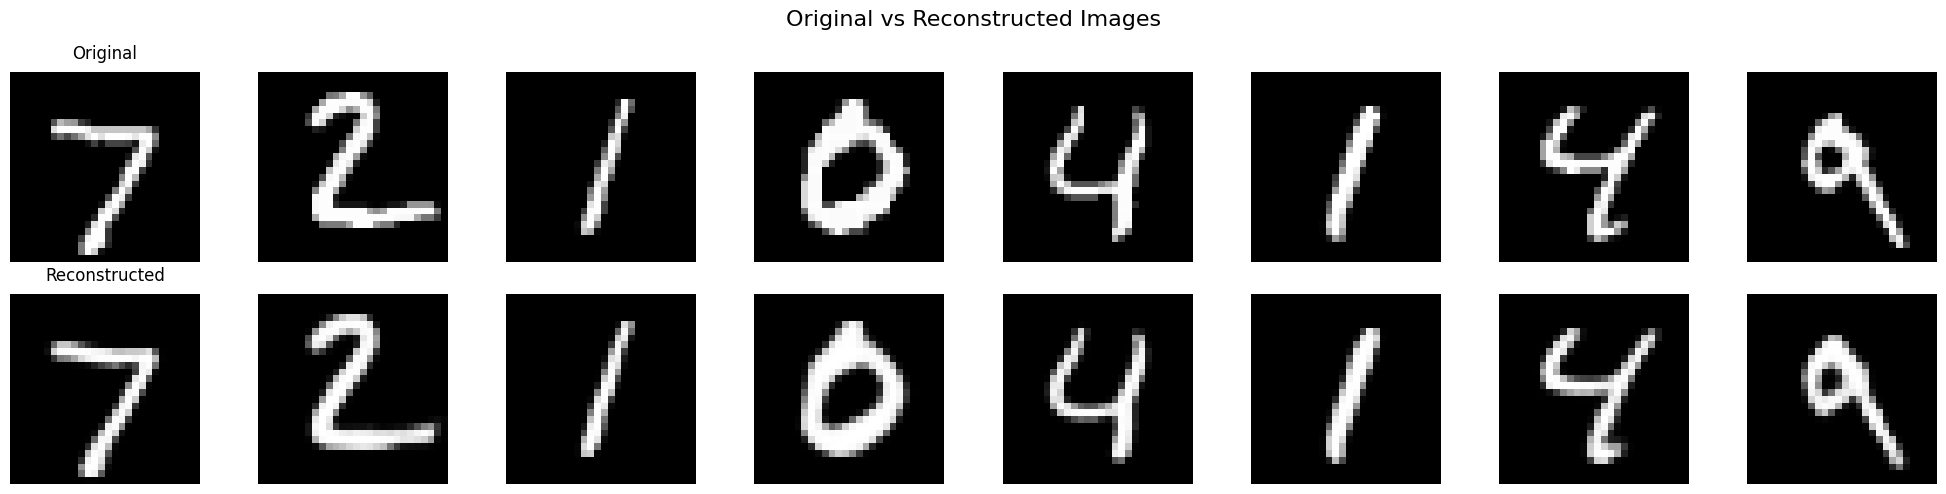

Reconstruction MSE: 0.0029


In [13]:
# Get test images
test_images, test_labels = next(iter(testloader))
test_images = test_images.to(cfg.device)

# Get reconstructions using the classifier and decoder
with torch.no_grad():
    # Get latent representations from classifier
    latent_reps, _ = backbone(test_images)  # Returns (latent_rep, logits)
    # Reconstruct using decoder
    reconstructions = decoder(latent_reps)

# Plot original and reconstructed images
fig, axes = plt.subplots(2, 8, figsize=(20, 5))
fig.suptitle('Original vs Reconstructed Images', fontsize=16)

# Plot original images
for i in range(8):
    axes[0,i].imshow(test_images[i].cpu().squeeze(), cmap='gray')
    axes[0,i].axis('off')
    if i == 0:
        axes[0,i].set_title('Original', pad=10)

# Plot reconstructions
for i in range(8):
    axes[1,i].imshow(reconstructions[i].cpu().squeeze(), cmap='gray')
    axes[1,i].axis('off')
    if i == 0:
        axes[1,i].set_title('Reconstructed', pad=10)

plt.tight_layout()
plt.show()

# Optionally, calculate reconstruction error
mse = nn.MSELoss()
recon_error = mse(reconstructions, test_images)
print(f'Reconstruction MSE: {recon_error.item():.4f}')

## Load autoencoder

In [14]:
from models.mnist_conv_autoencoder import MNISTConvAutoencoder
importlib.reload(models.mnist_conv_autoencoder)

autoencoders = []
for latent_dim in dimensions:
    autoencoder_save_path = os.path.join(models_dir, f'mnist_conv_autoencoder_{latent_dim}.pth')
    autoencoder = MNISTConvAutoencoder(device=cfg.device, model_save_path=autoencoder_save_path, latent_dim=latent_dim)
    autoencoder.load_model()
    autoencoders.append(autoencoder)

Model loaded from ../model_saves/big_test/mnist_conv_autoencoder_16.pth
Model loaded from ../model_saves/big_test/mnist_conv_autoencoder_32.pth
Model loaded from ../model_saves/big_test/mnist_conv_autoencoder_64.pth
Model loaded from ../model_saves/big_test/mnist_conv_autoencoder_128.pth
Model loaded from ../model_saves/big_test/mnist_conv_autoencoder_256.pth


### Test autoencoders

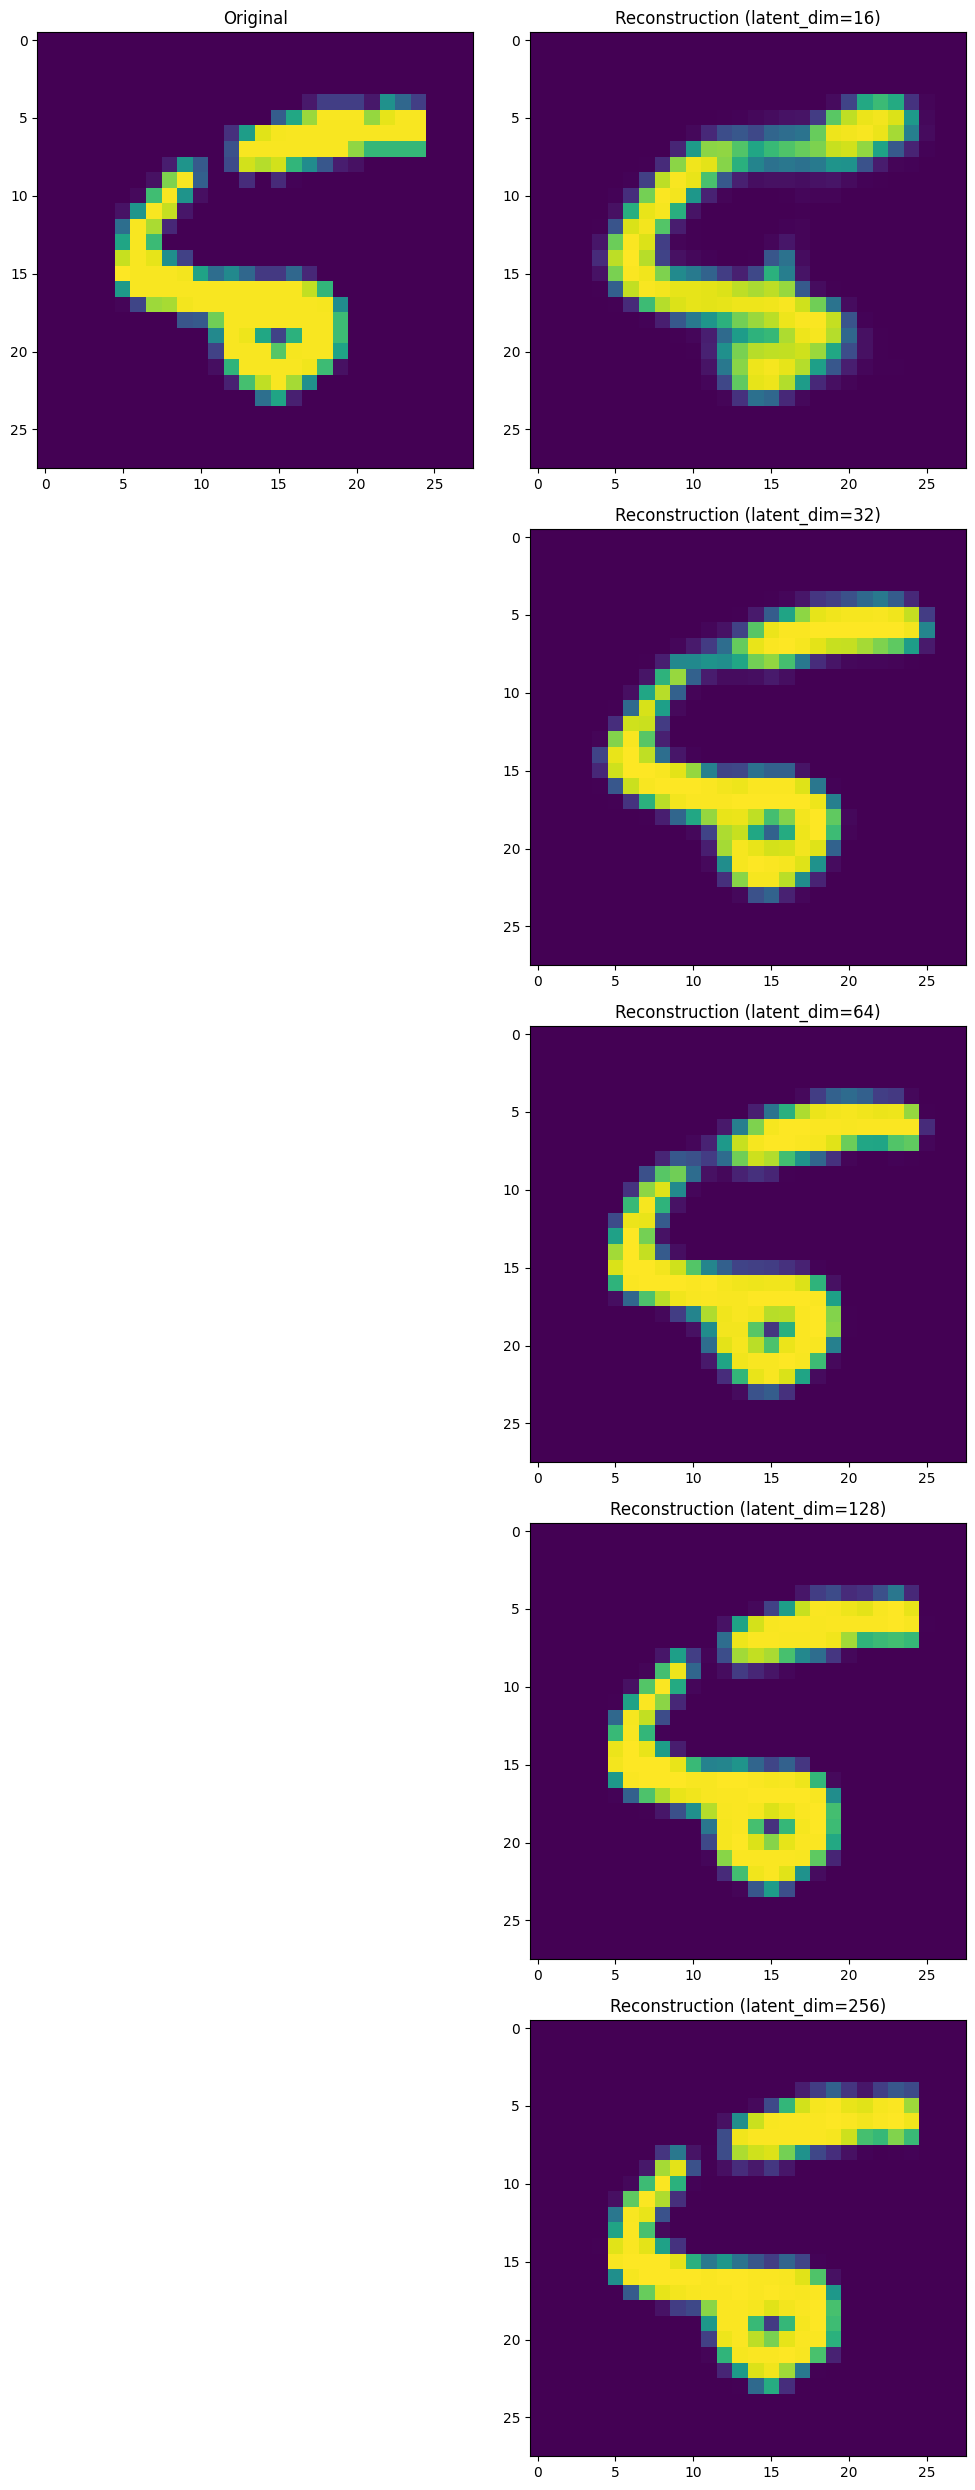

In [15]:
test_img, test_label = testloader.dataset[8]
test_img = test_img.unsqueeze(0).to(cfg.device)

plt.figure(figsize=(10, 5 * len(autoencoders)))

# Original image (only need to show once)
plt.subplot(len(autoencoders), 2, 1)
plt.imshow(test_img[0].cpu().permute(1, 2, 0))
plt.title("Original")

with torch.no_grad():
    for i, autoencoder in enumerate(autoencoders):
        z = autoencoder.encode(test_img)
        recon = autoencoder.decode(z)

        # Plot reconstruction for each autoencoder
        plt.subplot(len(autoencoders), 2, 2*(i+1))
        plt.imshow(recon[0].cpu().permute(1, 2, 0))
        plt.title(f"Reconstruction (latent_dim={dimensions[i]})")

plt.tight_layout()
plt.show()

## Evaluate CLUE

### Load the VAE

In [16]:
from models.VAE_likelihood import ConvVAELikelihoodEstimator

vae = ConvVAELikelihoodEstimator(latent_dim=20, device=cfg.device)

vae.load_state_dict(torch.load(os.path.join(base_dir, 'new_regene_models', 'vae_likelihood_estimator_20.pt'), map_location=cfg.device))


<All keys matched successfully>

### Get Uncertain Images

In [17]:
import importlib
import clue.evaluate_CLUE
importlib.reload(clue.evaluate_CLUE)
from clue.evaluate_CLUE import evaluate_clue_counterfactuals, find_uncertain_images, visualize_counterfactual_results, evaluate_single_clue_counterfactual

In [18]:
bll_vi = last_layer_models[4]
backbone = models_list[4][0]
decoder = models_list[4][1]


In [19]:
uncertain_images, uncertain_indices = find_uncertain_images(bll_vi, testloader, n=50, device=cfg.device)

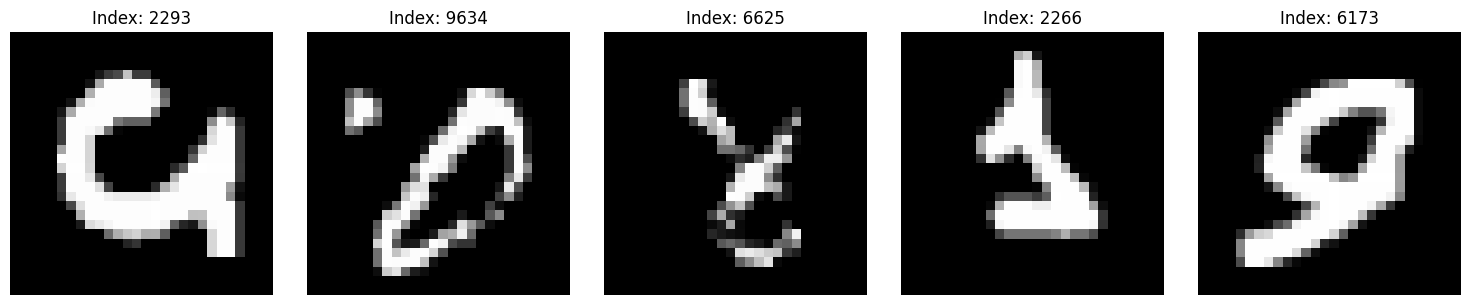

Uncertainty indices of these images: [2293, 9634, 6625, 2266, 6173]


In [20]:
# Plot the first 5 uncertain images
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(uncertain_images[i, 0].cpu(), cmap='gray')
    plt.title(f"Index: {uncertain_indices[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

print("Uncertainty indices of these images:", uncertain_indices[:5].tolist())

### Test a single image

In [ ]:
import clue.new_CLUE
importlib.reload(clue.new_CLUE)

bayesian = False

if bayesian:
    model = bll_vi
else:
    model = backbone

results, figure = evaluate_single_clue_counterfactual(
    uncertain_images[0],
    model,
    decoder,
    vae,
    device=cfg.device,
    verbose=True,
    steps=150,
    distance_weight=0.001,
    lr=0.2,
    target_class=9,
    bayesian=bayesian,
    ReconstructionOnly=True
)

## Test auxiliary autoencoder

In [25]:
# Import the counterfactual scorer
import models.counterfactual_scorer
importlib.reload(models.counterfactual_scorer)
from models.counterfactual_scorer import MNISTClassAutoencoders

# Initialize the class autoencoders with the correct model path
models_dir = '../model_saves/im1_autoencoders'
class_autoencoders = MNISTClassAutoencoders(latent_dim=32, device=cfg.device, models_dir=models_dir)

# Load the pre-trained models
try:
    class_autoencoders.load_models()
    print("Class-specific autoencoder models loaded successfully from", models_dir)
except Exception as e:
    print(f"Error loading class autoencoder models: {e}")
    print("Some models may not be initialized")

Loading autoencoder for digit 0...
Model loaded from ../model_saves/im1_autoencoders/mnist_autoencoder_class_0.pth
Loading autoencoder for digit 1...
Model loaded from ../model_saves/im1_autoencoders/mnist_autoencoder_class_1.pth
Loading autoencoder for digit 2...
Model loaded from ../model_saves/im1_autoencoders/mnist_autoencoder_class_2.pth
Loading autoencoder for digit 3...
Model loaded from ../model_saves/im1_autoencoders/mnist_autoencoder_class_3.pth
Loading autoencoder for digit 4...
Model loaded from ../model_saves/im1_autoencoders/mnist_autoencoder_class_4.pth
Loading autoencoder for digit 5...
Model loaded from ../model_saves/im1_autoencoders/mnist_autoencoder_class_5.pth
Loading autoencoder for digit 6...
Model loaded from ../model_saves/im1_autoencoders/mnist_autoencoder_class_6.pth
Loading autoencoder for digit 7...
Model loaded from ../model_saves/im1_autoencoders/mnist_autoencoder_class_7.pth
Loading autoencoder for digit 8...
Model loaded from ../model_saves/im1_autoenco

### Test autoencoder

In [ ]:
from clue.evaluate_CLUE import evaluate_single_auxiliary_clue_counterfactual, evaluate_single_clue_counterfactual
importlib.reload(clue.evaluate_CLUE)
import clue.new_CLUE
importlib.reload(clue.new_CLUE)
import models.BLL_VI
importlib.reload(models.BLL_VI)

bayesian = True

if bayesian:
    model = bll_vi
else:
    model = backbone

image, label = testloader.dataset[2]
target_class = 4

unsupervised_results, unsupervised_figure = evaluate_single_auxiliary_clue_counterfactual(
    image,
    model,
    autoencoder,
    device=cfg.device,
    verbose=False,
    steps=200,
    distance_weight=0.001,
    lr=0.2,
    bayesian=bayesian,
    target_class=target_class,
    vae=vae,
    counterfactual_scorer=class_autoencoders
)

supervised_results, supervised_figure = evaluate_single_clue_counterfactual(
    image,
    model,
    decoder,
    device=cfg.device,
    verbose=False,
    steps=200,
    distance_weight=0.001,
    lr=0.2,
    bayesian=bayesian,
    target_class=target_class,
    vae=vae,
    counterfactual_scorer=class_autoencoders
)

In [ ]:
unsupervised_recon_realism_dif = unsupervised_results['recon_counterfactual_realism_difference']
supervised_recon_realism_dif = supervised_results['recon_counterfactual_realism_difference']

unsupervised_realism_dif = unsupervised_results['realism_score_difference']
supervised_realism_dif = supervised_results['realism_score_difference']

unsupervised_im1 = unsupervised_results['im1_score']
supervised_im1 = supervised_results['im1_score']

print(f"Unsupervised Recon Realism Difference: {unsupervised_recon_realism_dif:.6f}")
print(f"Supervised Recon Realism Difference: {supervised_recon_realism_dif:.6f}")

print(f"Unsupervised Realism Difference: {unsupervised_realism_dif:.6f}")
print(f"Supervised Realism Difference: {supervised_realism_dif:.6f}")

print(f"Unsupervised IM1 Score: {unsupervised_im1:.6f}")
print(f"Supervised IM1 Score: {supervised_im1:.6f}")



In [ ]:


# Calculate IM1 score for both counterfactual images
original_img = image.unsqueeze(0).to(cfg.device)

# Compare supervised and unsupervised counterfactuals
supervised_cf = supervised_results['counterfactual_image'].to(cfg.device)
unsupervised_cf = unsupervised_results['counterfactual_image'].to(cfg.device)

# Calculate IM1 scores (lower is better, indicates a more realistic counterfactual)
supervised_im1 = class_autoencoders.calculate_im1(
    supervised_cf,
    original_class=label,
    counterfactual_class=target_class
)

unsupervised_im1 = class_autoencoders.calculate_im1(
    unsupervised_cf,
    original_class=label,
    counterfactual_class=target_class
)

print(f"Original class: {label}")
print(f"Counterfactual class: {target_class}")
print(f"Supervised IM1 Score: {supervised_im1:.6f} (lower is better)")
print(f"Unsupervised IM1 Score: {unsupervised_im1:.6f} (lower is better)")

# Get reconstructions from both class-specific autoencoders for both counterfactuals
supervised_orig_recon = class_autoencoders.get_reconstruction(supervised_cf, label)
supervised_cf_recon = class_autoencoders.get_reconstruction(supervised_cf, target_class)

unsupervised_orig_recon = class_autoencoders.get_reconstruction(unsupervised_cf, label)
unsupervised_cf_recon = class_autoencoders.get_reconstruction(unsupervised_cf, target_class)

# Visualize the original, counterfactuals, and their reconstructions
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Original image
axes[0, 0].imshow(original_img.cpu().squeeze().numpy(), cmap='gray')
axes[0, 0].set_title(f"Original (Class {label})")
axes[0, 0].axis('off')

# Supervised counterfactual
axes[0, 1].imshow(supervised_cf.cpu().squeeze().numpy(), cmap='gray')
axes[0, 1].set_title(f"Supervised CF (Target: {target_class})")
axes[0, 1].axis('off')

# Supervised reconstructions
axes[0, 2].imshow(supervised_orig_recon.cpu().squeeze().numpy(), cmap='gray')
axes[0, 2].set_title(f"Supervised CF\nRecon as Class {label}")
axes[0, 2].axis('off')

axes[0, 3].imshow(supervised_cf_recon.cpu().squeeze().numpy(), cmap='gray')
axes[0, 3].set_title(f"Supervised CF\nRecon as Class {target_class}")
axes[0, 3].axis('off')

# Unsupervised counterfactual
axes[1, 0].imshow(original_img.cpu().squeeze().numpy(), cmap='gray')
axes[1, 0].set_title(f"Original (Class {label})")
axes[1, 0].axis('off')

axes[1, 1].imshow(unsupervised_cf.cpu().squeeze().numpy(), cmap='gray')
axes[1, 1].set_title(f"Unsupervised CF (Target: {target_class})")
axes[1, 1].axis('off')

# Unsupervised reconstructions
axes[1, 2].imshow(unsupervised_orig_recon.cpu().squeeze().numpy(), cmap='gray')
axes[1, 2].set_title(f"Unsupervised CF\nRecon as Class {label}")
axes[1, 2].axis('off')

axes[1, 3].imshow(unsupervised_cf_recon.cpu().squeeze().numpy(), cmap='gray')
axes[1, 3].set_title(f"Unsupervised CF\nRecon as Class {target_class}")
axes[1, 3].axis('off')

plt.tight_layout()
plt.show()


### Test multiple

In [37]:
# Get 50 random images from the test set
import random
import torch

# Set random seed for reproducibility
random.seed(30)
torch.manual_seed(30)

# Number of images to select
num_images = 50

# Get random indices from the test set
random_indices = random.sample(range(len(testset)), num_images)

# Get the images and their true labels
random_images = []
true_labels = []

for idx in random_indices:
    img, label = testset[idx]
    random_images.append(img.unsqueeze(0))  # Add batch dimension
    true_labels.append(label)

# Stack images into a single tensor
random_images = torch.cat(random_images, dim=0)

# Generate random target labels that are different from the true labels
target_labels = []
for true_label in true_labels:
    # Get all possible labels except the true one
    possible_labels = list(range(10))  # Assuming 10 classes (0-9) for MNIST
    possible_labels.remove(true_label)
    # Randomly select one of the remaining labels
    target_label = random.choice(possible_labels)
    target_labels.append(target_label)

print(f"Selected {num_images} random images with their true labels:")
print(f"True labels: {true_labels}")
print(f"Target labels: {target_labels}")



Selected 50 random images with their true labels:
True labels: [4, 4, 2, 8, 7, 0, 9, 0, 9, 6, 1, 7, 0, 3, 2, 5, 0, 7, 6, 4, 3, 1, 6, 7, 1, 7, 0, 9, 9, 4, 7, 7, 7, 1, 9, 8, 8, 5, 7, 9, 1, 1, 1, 9, 7, 7, 8, 1, 1, 1]
Target labels: [2, 9, 3, 7, 5, 9, 7, 6, 8, 5, 2, 0, 2, 8, 8, 4, 8, 4, 4, 2, 2, 3, 9, 4, 7, 3, 4, 7, 5, 7, 4, 9, 6, 7, 4, 7, 5, 4, 9, 2, 3, 5, 9, 5, 0, 3, 1, 6, 9, 0]


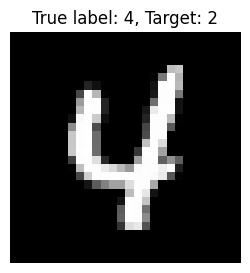

In [38]:
# Display the first random image
plt.figure(figsize=(3, 3))
plt.imshow(random_images[0].squeeze().cpu().numpy(), cmap='gray')
plt.title(f"True label: {true_labels[0]}, Target: {target_labels[0]}")
plt.axis('off')
plt.show()

Run multiple clue to test

BIG IMPORTANT TEST CELL

In [40]:
importlib.reload(clue.evaluate_CLUE)
from clue.evaluate_CLUE import evaluate_class_counterfactuals, save_class_counterfactual_results_to_csv, save_class_counterfactual_images

results_list = {}

for i in range(len(last_layer_models)):
    dim = models_list[i][3]
    print(f"Running for dimension {dim}")

    inner_results_list = {}

    # Run all four combinations of bayesian and auxiliary models
    combinations = [
        {"bayesian": False, "use_auxiliary": False, "name": "Supervised Deterministic"},
        {"bayesian": False, "use_auxiliary": True, "name": "Unsupervised Deterministic"},
        {"bayesian": True, "use_auxiliary": False, "name": "Supervised Bayesian"},
        {"bayesian": True, "use_auxiliary": True, "name": "Unsupervised Bayesian"}
    ]

    for combo in combinations:
        bayesian = combo["bayesian"]
        use_auxiliary = combo["use_auxiliary"]

        print(f"\nRunning {combo['name']}:")

        if bayesian:
            model = last_layer_models[i]
        else:
            model = models_list[i][0]

        if use_auxiliary:
            ae = autoencoders[i]
        else:
            ae = None

        results = evaluate_class_counterfactuals(
            random_images,
            model,
            models_list[i][1],
            vae,
            device=cfg.device,
            steps=150,
            lr=0.4,
            distance_weight=0.001,
            bayesian=bayesian,
            target_classes=target_labels,
            autoencoder=ae,
            counterfactual_scorer=class_autoencoders
        )

        save_class_counterfactual_results_to_csv(results, output_dir=results_dir, suffix=f'big_test_{dim}_{combo["name"]}')
        save_class_counterfactual_images(results, output_dir=os.path.join(results_dir, f'big_test_{dim}_{combo["name"]}'))

        inner_results_list[combo['name']] = results
        results_list[dim] = inner_results_list

Output hidden; open in https://colab.research.google.com to view.

In [41]:
print(results_list[16]['Supervised Deterministic'].keys())
importlib.reload(clue.evaluate_CLUE)
from clue.evaluate_CLUE import save_aggregate_comparison_to_csv
importlib.reload(clue.evaluate_CLUE)

save_aggregate_comparison_to_csv(results_list, output_dir=results_dir, filename=f'big_test_aggregate_comparison_test.csv')


dict_keys(['avg_target_class_confidence', 'avg_latent_target_class_confidence', 'avg_latent_distance', 'individual_results', 'avg_original_log_likelihood', 'avg_reconstruction_log_likelihood', 'avg_counterfactual_log_likelihood', 'avg_log_likelihood_difference', 'avg_recon_counterfactual_log_likelihood_difference', 'median_log_likelihood_difference', 'median_recon_counterfactual_log_likelihood_difference', 'avg_likelihood_ratio', 'avg_recon_counterfactual_likelihood_ratio', 'median_likelihood_ratio', 'median_recon_counterfactual_likelihood_ratio', 'avg_original_realism_score', 'avg_reconstruction_realism_score', 'avg_counterfactual_realism_score', 'avg_realism_score_difference', 'avg_recon_counterfactual_realism_difference', 'median_realism_score_difference', 'median_recon_counterfactual_realism_difference', 'avg_im1_score'])
Comparison results saved to: ../results/big_test_2/big_test_aggregate_comparison_test_2025-04-10_18-32-54.csv


'../results/big_test_2/big_test_aggregate_comparison_test_2025-04-10_18-32-54.csv'

In [ ]:
avg_realism_score_diff = results['avg_realism_score_difference']
avg_im1_score = results['avg_im1_score']

print(f"Average Realism Score Difference: {avg_realism_score_diff:.6f}")
print(f"Average IM1 Score: {avg_im1_score:.6f}")


In [ ]:
from clue.evaluate_CLUE import visualize_class_counterfactual_results
visualize_class_counterfactual_results(results, n=1)

In [ ]:
from clue.evaluate_CLUE import save_class_counterfactual_results_to_csv
importlib.reload(clue.evaluate_CLUE)

save_class_counterfactual_results_to_csv(results, output_dir=results_dir, suffix='random_test_temp_extra')

In [ ]:
importlib.reload(clue.evaluate_CLUE)
from clue.evaluate_CLUE import save_class_counterfactual_images
save_class_counterfactual_images(results, output_dir=os.path.join(results_dir, 'random_test_temp_extra'))